# Python Lesson 38: Log-loss and Maximum Likelihood

**Concept page:** `wiki/concepts/log-loss-and-maximum-likelihood.md` · **Area:** probability

**You will be able to:**
- compute likelihood and log-likelihood of coin tosses
- find the maximiser p̂ = k/n
- write binary log-loss and its gradient

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Which coin explains HHHHHHHTTT?

In [2]:
for p in (0.7,0.5,0.3): print(p, p**7*(1-p)**3)

0.7 0.0022235661
0.5 0.0009765625
0.3 7.501409999999996e-05


## 2. Maximise likelihood vs log-likelihood

0.7000000000000001 0.7000000000000001


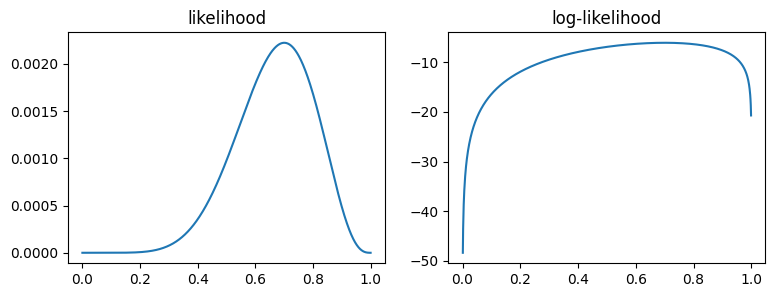

In [3]:
p=np.linspace(0.001,0.999,999)
lik=p**7*(1-p)**3; ll=7*np.log(p)+3*np.log(1-p)
print(p[np.argmax(lik)], p[np.argmax(ll)])
fig,ax=plt.subplots(1,2,figsize=(9,3)); ax[0].plot(p,lik); ax[0].set_title("likelihood"); ax[1].plot(p,ll); ax[1].set_title("log-likelihood"); plt.show()

## 3. Why logs: underflow

In [4]:
probs=np.full(5000,0.3); print("product:",np.prod(probs),"  sum of logs:",np.log(probs).sum())

product: 0.0   sum of logs: -6019.864021629681


## 4. Binary log-loss and its gradient wrt the logit

In [5]:
def logloss(y,yhat): return -(y*np.log(yhat)+(1-y)*np.log(1-yhat))
sig=lambda z:1/(1+np.exp(-z))
z=0.3; y=1
num=(logloss(y,sig(z+1e-6))-logloss(y,sig(z-1e-6)))/2e-6
print(num, sig(z)-y)    # d L / d z = yhat - y

-0.42555748319683673 -0.42555748318834097


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 12 advanced p. 151: P(HHTT) = (2/3)²(1/3)² for a biased coin — products of independent probabilities, the starting point for likelihood.

In [6]:
print((2/3)**2*(1/3)**2)

0.04938271604938271


## Exercises

**Exercise 1.** Given 6 heads in 10 tosses, find the MLE of p by grid search (0.6).

In [7]:
# your code here

**Exercise 2.** Compute the mean log-loss of predictions [0.9,0.2,0.7] for labels [1,0,1].

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
p=np.linspace(0.001,0.999,999); print(p[np.argmax(6*np.log(p)+4*np.log(1-p))])

0.6


In [10]:
# Solution 2
y=np.array([1,0,1]); yh=np.array([0.9,0.2,0.7]); print(logloss(y,yh).mean())

0.22839300363692283
